# Lab 6 CNNs
Group Members: David Guo, Zi Ling

## 1. Preparation

### 1.1 Dataset Introduction

We use the same dataset we have in Lab2, which is the Garbage Classification Dataset from Kaggle (https://www.kaggle.com/datasets/zlatan599/garbage-dataset-classification/data). 

It provides a clean and well-balanced collection of images for automated waste-sorting tasks. The orginal dataset contains 6 categories of cardboard, glass, metal, paper, plastics, and trash, and for each category has 2,300 to 2,500 256x256x3 RGB images.

### 1.2 Resize, Grayscale and Train/test Split

In [34]:
# Thanks Keras for making img loading so easy: https://keras.io/api/data_loading/image/
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

train_ds = keras.utils.image_dataset_from_directory(
	"images",
	labels="inferred", 
	label_mode="int", # turn labels into 0,1,2,... # note: + sparse_categorical_crossentropy
	color_mode="grayscale",
	batch_size=64,
	image_size=(64, 64),   
	shuffle=True,
	seed=42,
	validation_split=0.2,
	subset="training"
)

test_ds = keras.utils.image_dataset_from_directory(
	"images",
	labels="inferred",
	label_mode="int",
	color_mode="grayscale",
	batch_size=64,
	image_size=(64, 64),
	shuffle=True,
	seed=42,
	validation_split=0.2,
	subset="validation"
)

train_class_names = train_ds.class_names
test_class_names = test_ds.class_names

print("Train", train_class_names)
print("Test", test_class_names)

Found 13899 files belonging to 6 classes.
Using 11120 files for training.
Found 13899 files belonging to 6 classes.
Using 2779 files for validation.
Train ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Test ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


(64, 64, 64, 1)


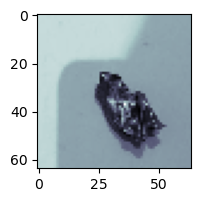

(64, 64, 64, 1)


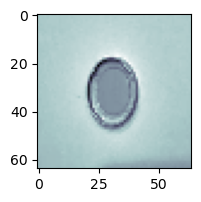

(64, 64, 64, 1)


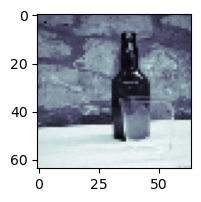

(64, 64, 64, 1)


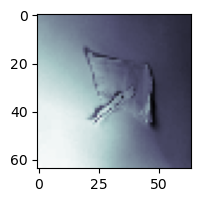

(64, 64, 64, 1)


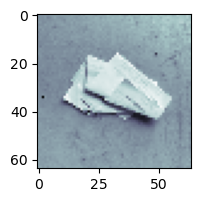

In [35]:
import matplotlib.pyplot as plt

for images, labels in train_ds.take(5):
	plt.figure(figsize=(2, 2))
	print(images.shape)
	plt.imshow(images[0].numpy().squeeze(), cmap="bone")
	plt.show()

In [36]:
# ask GPT to give me the simplest code to count number of labels in a tf dataset
from collections import Counter

def count_labels(ds, class_names):
	counter = Counter()

	for _, labels in ds:
		counter.update(labels.numpy())

	return {class_names[i]: counter[i] for i in range(len(class_names))}

train_counts = count_labels(train_ds, train_ds.class_names)
test_counts = count_labels(test_ds, test_ds.class_names)

print("Train counts:", train_counts)
print("Val counts:", test_counts)

#Normalizing the dataset
def normalize_image(image, label):
		# Scale pixel values to [0, 1]
		image = image / 255.0
		return image, label

train_ds = train_ds.map(normalize_image)
test_ds = test_ds.map(normalize_image)

train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
test_ds  = test_ds.prefetch(tf.data.AUTOTUNE)

Train counts: {'cardboard': 1775, 'glass': 2026, 'metal': 1667, 'paper': 1838, 'plastic': 1824, 'trash': 1990}
Val counts: {'cardboard': 437, 'glass': 474, 'metal': 417, 'paper': 477, 'plastic': 464, 'trash': 510}


To prepare the dataset for modeling, we used Keras’s image_dataset_from_directory, which automatically loads images and assigns labels based on the folder names. The labels were stored as integer class IDs, which allows us to train our CNN using sparse_categorical_crossentropy without converting them into one-hot vectors.

All images were resized to 64×64 pixels and grayscaled, to simplify computation while still preserving meaningful visual information for classification. They plot shows the reshaped images are still able to recongized.

For the Train/Test split, We applied an 80/20 stratified split using the built-in validation_split=0.2 and subset="training"/"validation" options. This ensures that both the training and test sets maintain the original class distribution. Although the dataset is not perfectly even across the six categories, the distribution is still reasonably balanced, with each class containing roughly 2,000–2,500 samples. This level of balance is sufficient for supervised deep learning and does not require more complex splitting strategies such as k-fold cross-validation.

The final result is two clean, normalized, and well-structured datasets (train_ds and test_ds) ready for data augmentation and CNN modeling.

### 1.3 Measure of Performance Discussion
For this task, accuracy alone is not enough because it does not reflect which types of mistakes are more harmful. In real garbage-sorting systems, some categories such as glass, metal, and trash are higher-risk—missing them can cause contamination or safety issues. Other categories like paper, cardboard, and plastic are lower-risk, and confusion among them is less serious.

Because different classes have different risks, using a single F1-score for all of them is not appropriate. F1 gives precision and recall equal weight, but high-risk categories require stronger emphasis on recall, since missing these items is more costly than detecting too many.

Therefore, we evaluate each class separately using:
1. F2-score (recall-weighted) for high-risk classes: glass, metal, trash.
2. F1-score for lower-risk classes: cardboard, paper, plastic.

Finally, we take the simple average of the six F-scores as our overall performance metric. 

This keeps the metric easy to interpret while reflecting the real priorities of a garbage-sorting system.

# 2. Modeling

### 2.1 Data Augmentation

In [37]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import RandomFlip, RandomRotation
cnn = Sequential()

# add in augmentations directly
cnn.add(RandomFlip("horizontal"))
cnn.add(RandomRotation(0.2))

In our CNN architecture, we apply data augmentation directly within the model using RandomFlip and RandomRotation. These layers introduce small, realistic variations in each training image, such as horizontal flips and slight rotations. This helps the model generalize better by preventing it from memorizing specific image orientations or positions. Since garbage images in real-world environments can appear at arbitrary angles and arrangements, these augmentation techniques improve robustness and reduce overfitting.

### 2.2 Creating Models

### 2.2.1 Model 1 1-Layer CNN

Epoch 1/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.2812 - loss: 1.7648 - val_accuracy: 0.3580 - val_loss: 1.6078
Epoch 2/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.3603 - loss: 1.5957 - val_accuracy: 0.3724 - val_loss: 1.6081
Epoch 3/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.3781 - loss: 1.5611 - val_accuracy: 0.3231 - val_loss: 1.8102
Epoch 4/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.3891 - loss: 1.5365 - val_accuracy: 0.3865 - val_loss: 1.6317
Epoch 5/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.4017 - loss: 1.5229 - val_accuracy: 0.4019 - val_loss: 1.5623
Epoch 6/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.4091 - loss: 1.5041 - val_accuracy: 0.4520 - val_loss: 1.4522
Epoch 7/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.4164 - loss: 1.4913 - val_accuracy: 0.4102 - val_loss: 1.6695
Epoch 8/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.4214 - loss: 1.4841 - val_accu

Model: "Model1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_6 (RandomFlip)      │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_6               │ (None, 64, 64, 1)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation_4            │ (None, 64, 64, 1)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 6)              │       196,614 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 393,870 (1.50 MB)

 Trainable params: 196,934 (769.27 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 196,936 (769.29 KB)

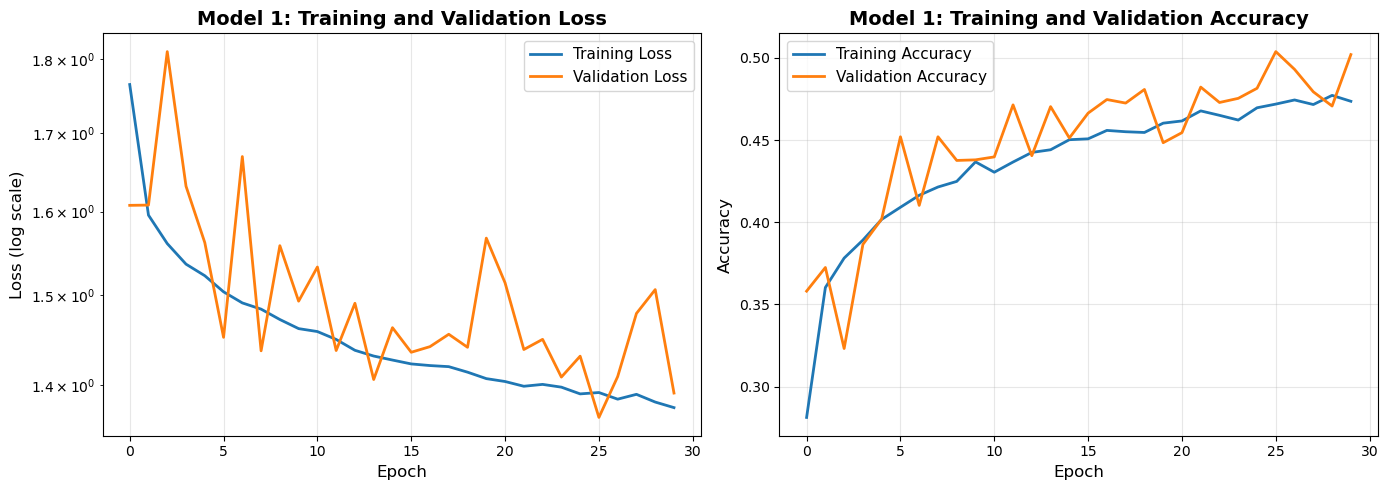

In [38]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dense, Dropout, Activation, Flatten, Concatenate
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomTranslation
from tensorflow.keras.layers import RandomContrast, RandomBrightness

def create_cnn_model_1(model_name, input_shape = [64,64,1], kernel_size= (3,3), pool_size=(2,2), 
					 filters_per_conv_layer = [32], # number of filters to use and how many convolutional layers to use 
					 dense_layer_sizes = [6], # number of neurons in each layer after flattening
					 use_dropout=False
					):
	
	cnn  = Sequential(name=model_name)
	cnn.add(Input(input_shape))

	cnn.add(RandomFlip("horizontal")) # flip horizontally
	cnn.add(RandomRotation(0.05)) # rotate by 5%
	cnn.add(RandomTranslation(height_factor=0.1, width_factor=0.1)) # move by 10%

	# convolutional layers
	for num_filters in filters_per_conv_layer:
		cnn.add(Conv2D(filters=num_filters, 
						kernel_size=kernel_size, 
						padding='same',
						activation='relu',
						 ))
		
		cnn.add(MaxPooling2D(pool_size=pool_size))
		
	cnn.add(Flatten())
	for i, num_hidden in enumerate(dense_layer_sizes[:-1]):
		cnn.add(Dense(num_hidden, activation='relu'))
		# optionally use Dropout
		if use_dropout and i < len(dense_layer_sizes[:-1]) - 1:
			cnn.add(Dropout(0.2))
			
	# final layer for classes
	cnn.add(Dense(dense_layer_sizes[-1], activation='softmax'))
	
	return cnn

model_1 = create_cnn_model_1("Model1")

model_1.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop', metrics=['accuracy'])

history1 = model_1.fit(train_ds, validation_data=test_ds, batch_size=32, epochs=30, shuffle=True, verbose=1)

model_1.summary()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot (log scale)
axes[0].semilogy(history1.history['loss'], label='Training Loss', linewidth=2)
axes[0].semilogy(history1.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss (log scale)', fontsize=12)
axes[0].set_title('Model 1: Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history1.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[1].plot(history1.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Model 1: Training and Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Analysis

Model 1 is a simple forward feed cnn model with a kernel size of 3x3 and a filter of 32, with a single dense layer of 6. After running the model and graphing it for the loss on the graph, we see that the model's training loss has converged, while the validation is flunctuating. While it doesn't show that the model is overfitting, it clearly shows that the model is struggling to be trained on. This is due to us creating a one filter layer with a small 1x1 kernel size, which does not extract useful information for the model to be trained on. 

Overall, the model 1 is too simple so it can not learn much due to the one layer, and a kernel size of 1x1 which is heavily restricts its learning ability.

### 2.2.2 Model 2

Epoch 1/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 11s 55ms/step - accuracy: 0.1960 - loss: 1.7854 - val_accuracy: 0.2213 - val_loss: 1.7617
Epoch 2/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 9s 54ms/step - accuracy: 0.2457 - loss: 1.7391 - val_accuracy: 0.2702 - val_loss: 1.6808
Epoch 3/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step - accuracy: 0.2924 - loss: 1.6803 - val_accuracy: 0.3177 - val_loss: 1.6251
Epoch 4/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 9s 54ms/step - accuracy: 0.3417 - loss: 1.6198 - val_accuracy: 0.4210 - val_loss: 1.5085
Epoch 5/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 9s 54ms/step - accuracy: 0.3749 - loss: 1.5603 - val_accuracy: 0.4394 - val_loss: 1.4264
Epoch 6/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 9s 54ms/step - accuracy: 0.4084 - loss: 1.5127 - val_accuracy: 0.4480 - val_loss: 1.4131
Epoch 7/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 9s 54ms/step - accuracy: 0.4246 - loss: 1.4728 - val_accuracy: 0.4721 - val_loss: 1.4124
Epoch 8/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 9s 54ms/step - accuracy: 0.4458 - loss: 1.4387 - val_ac

Model: "Model1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_7 (RandomFlip)      │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_7               │ (None, 64, 64, 1)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation_5            │ (None, 64, 64, 1)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │       524,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,239,470 (4.73 MB)

 Trainable params: 619,734 (2.36 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 619,736 (2.36 MB)

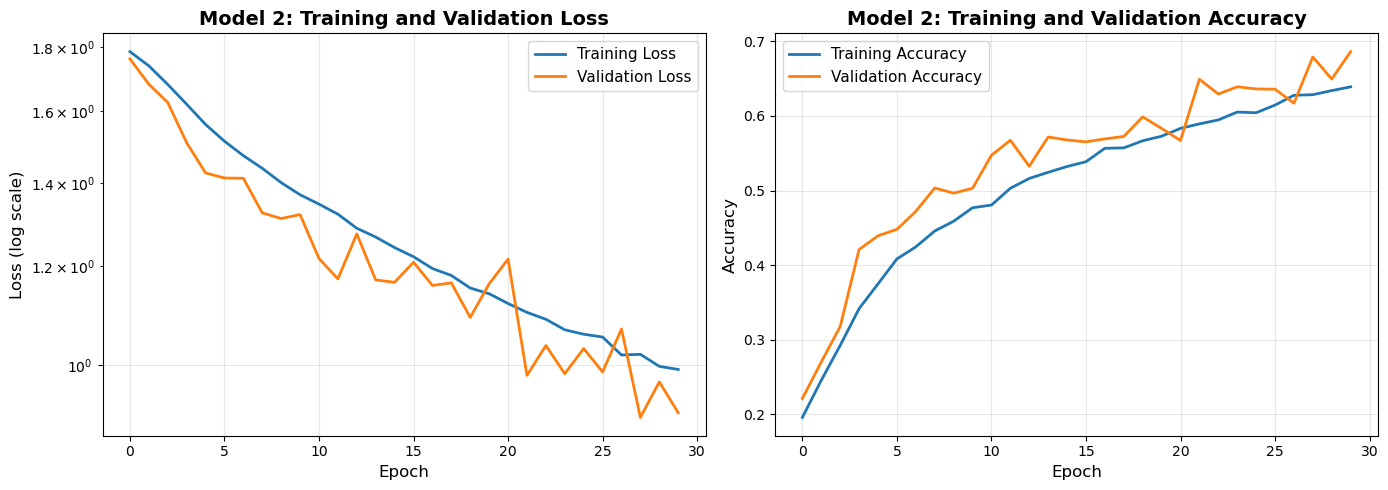

In [39]:
model_2 = create_cnn_model_1("Model1", 
															kernel_size=(3,3), 
															pool_size=(2,2), 
															filters_per_conv_layer = [32, 64, 128], 
															dense_layer_sizes = [64, 32, 16, 6], 
															use_dropout=True
															)

model_2.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop', metrics=['accuracy'])

history2 = model_2.fit(train_ds, validation_data=test_ds, batch_size=32, epochs=30, shuffle=True, verbose=1)

model_2.summary()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot (log scale)
axes[0].semilogy(history2.history['loss'], label='Training Loss', linewidth=2)
axes[0].semilogy(history2.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss (log scale)', fontsize=12)
axes[0].set_title('Model 2: Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history2.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[1].plot(history2.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Model 2: Training and Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Analysis

For model 2 we added 3 filter layers of 32, 64, and 128, along with a 4 dense layer of 64, 32, 16, and 6. The kernel size remains the same for all filter layers at 3x3. We are using dropout along with data augmentation to help preventing overfitting.

The loss curves shows that both training, and validation are converging, the training has a smooth curve, while the validation is showing flucuanting result. The loss curves for both are close to another showning that the model is not overfitting the data, and it shows that the model is able to learn well from the filter layers. 

The accuracy accuracy achieves is really high, with around 66% for validation, and 64% for training. The upwards trends supports that the model is learning well from the feature it is extracting from. 

### 2.2.3 Model 3

In [ ]:
# Asked Gpt to help with a debugging for parallel network
def create_branches(input, layers):
	branch = input
	for filters_per_conv_layer, kernel_size in layers:
		branch = Conv2D(filters=filters_per_conv_layer, kernel_size=kernel_size, padding='same', activation='relu')(branch)
		
	return branch


def create_cnn_model_2(input_shape = [64,64,1], pool_size=(2,2), 
										 num_branches = [
											[(32, (3,3))], 
											[(32, (1,1)), (64, (3,3))],
											[(32, (1,1)), (64, (3,3)), (64, (3,3))]
										 ], # number of filters to use and how many convolutional layers to use 
										 dense_layer_sizes = [6], # number of neurons in each layer after flattening
										 use_dropout=False
										):
		
	input = Input(input_shape)
	
	x = RandomFlip("horizontal")(input) # flip horizontally
	x = RandomRotation(0.05)(x) # rotate by 5%
	x = RandomTranslation(height_factor=0.1, width_factor=0.1)(x) # move by 10%
	x = RandomBrightness(factor=0.1, value_range=(0.0, 1.0))(x) # add some to the mean
	x = RandomContrast(0.1)(x) # add or decrease contrast


	#Create another Con2D here and then do max pool and then do branches
	x = Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu')(x)
	x = MaxPooling2D(pool_size=pool_size)(x)

	parallel_pathways_list = []
	# convolutional layers
	for branches_config in num_branches:
		result = create_branches(x, branches_config)
		parallel_pathways_list.append(result)
	
	x = Concatenate(axis=-1)(parallel_pathways_list)	
	x = MaxPooling2D(pool_size=pool_size)(x)

	x = Flatten()(x)

	for i, num_hidden in enumerate(dense_layer_sizes[:-1]):
		x = Dense(num_hidden, activation='relu')(x)
		# optionally use Dropout
		if use_dropout and i < len(dense_layer_sizes[:-1]) - 1:
			x = Dropout(0.2)(x)

	# final layer for classes
	x = Dense(dense_layer_sizes[-1], activation='softmax')(x)
	
	return Model(inputs=input, outputs=x, name='Inception')

Epoch 1/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 20s 106ms/step - accuracy: 0.1978 - loss: 1.7805 - val_accuracy: 0.2983 - val_loss: 1.7109
Epoch 2/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 18s 106ms/step - accuracy: 0.2553 - loss: 1.7181 - val_accuracy: 0.3210 - val_loss: 1.6494
Epoch 3/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 18s 105ms/step - accuracy: 0.2877 - loss: 1.6817 - val_accuracy: 0.3296 - val_loss: 1.6018
Epoch 4/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 18s 105ms/step - accuracy: 0.3138 - loss: 1.6479 - val_accuracy: 0.3771 - val_loss: 1.5451
Epoch 5/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 18s 104ms/step - accuracy: 0.3244 - loss: 1.6262 - val_accuracy: 0.3829 - val_loss: 1.5399
Epoch 6/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 18s 103ms/step - accuracy: 0.3438 - loss: 1.5956 - val_accuracy: 0.4120 - val_loss: 1.4900
Epoch 7/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 18s 103ms/step - accuracy: 0.3529 - loss: 1.5877 - val_accuracy: 0.4207 - val_loss: 1.4772
Epoch 8/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 18s 104ms/step - accuracy: 0.3546 - loss: 1

Model: "Inception"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 64, 64, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_flip_8       │ (None, 64, 64, 1) │          0 │ input_layer_6[0]… │
│ (RandomFlip)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_rotation_8   │ (None, 64, 64, 1) │          0 │ random_flip_8[0]… │
│ (RandomRotation)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_translation… │ (None, 64, 64, 1) │          0 │ random_rotation_… │
│ (RandomTranslation) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_brightness_2 │ (None, 64, 64, 1) │          0 │ random_translati… │
│ (RandomBrightness)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_contrast_2   │ (None, 64, 64, 1) │          0 │ random_brightnes… │
│ (RandomContrast)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 64, 64,    │        640 │ random_contrast_… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_12    │ (None, 32, 32,    │          0 │ conv2d_19[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 32, 32,    │      2,080 │ max_pooling2d_12… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 32, 32,    │     18,464 │ max_pooling2d_12… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 32, 32,    │     18,496 │ conv2d_21[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 32, 32,    │          0 │ conv2d_20[0][0],  │
│ (Concatenate)       │ 96)               │            │ conv2d_22[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_13    │ (None, 16, 16,    │          0 │ concatenate_2[0]… │
│ (MaxPooling2D)      │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_6 (Flatten) │ (None, 24576)     │          0 │ max_pooling2d_13… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 64)        │  1,572,928 │ flatten_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 64)        │          0 │ dense_18[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 32)        │      2,080 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 32)        │          0 │ dense_19[0][0]    │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 4,845,956 (18.49 MB)

 Trainable params: 1,615,318 (6.16 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,230,638 (12.32 MB)

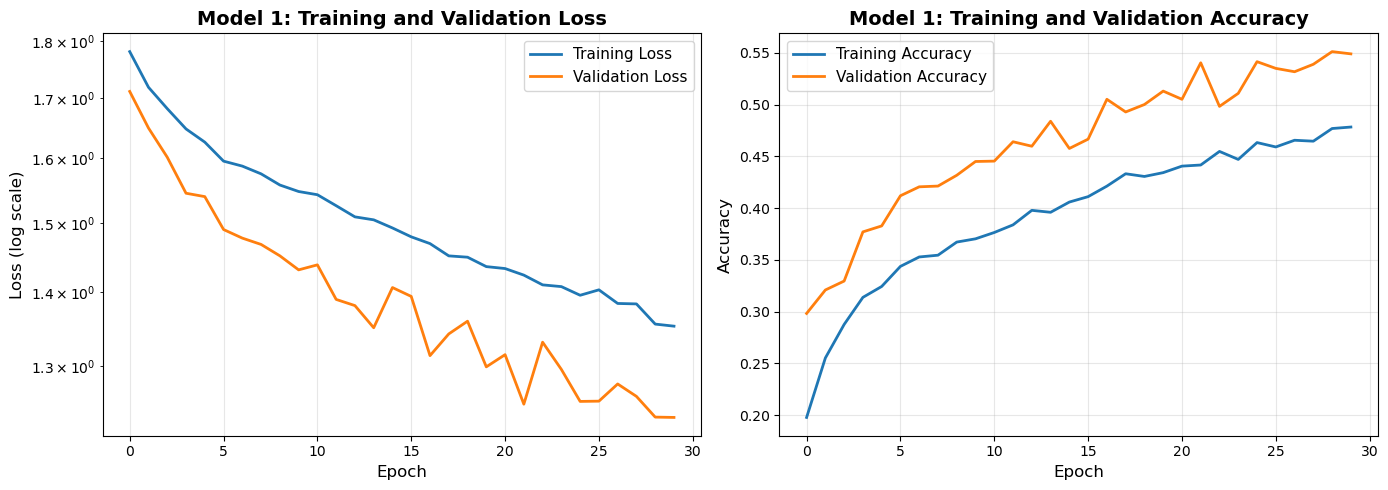

In [ ]:
model_3 = create_cnn_model_2(num_branches = [
											[(32, (3,3))], 
											[(32, (1,1)), (64, (3,3))],
										 ], dense_layer_sizes = [64, 32, 16, 6], use_dropout=True)

model_3.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history3 = model_3.fit(train_ds, validation_data=test_ds, batch_size=32, epochs=30, shuffle=True, verbose=1)

model_3.summary()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot (log scale)
axes[0].semilogy(history3.history['loss'], label='Training Loss', linewidth=2)
axes[0].semilogy(history3.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss (log scale)', fontsize=12)
axes[0].set_title('Model 1: Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history3.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[1].plot(history3.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Model 1: Training and Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Analysis

For model 3, we are using parrallel pathways with 1 branch of 32 filter, and a kernel size of 3x3. The second branch is using 2 convulatiion layer of 32 filter with a kernel size of 1x1, and a second layer of 64 filter with a 3x3 kernel size. We deciede to go with two branches as the branch 1 can be used to extract low level features, while the second branch can capture more information from the image with its two conculation layers. After concatenating them, we apply a maxpooling of size 2x2 with the deafult stride which gets the max value, and this is passed to the dense layer of 64, 32, 16, 6 with a dropout of 0.2 between hidden layers to reduce overfitting. 

Both the trainning, and the validation curve loss are converging, showing that the model is learning effectively. The fluctating validation loss could be due to dropout, and data augmentation happening during training phase. Moreover, the validation is close to the training loss indicating the model is not overfitting, and the model is learning steadily after each epochs. 

The loss curve trend also supports the accuracy curve where the accuracy is increasing after each epochs, and the reason the validation is higher than the training as the data augmentation and dropout only happens during the training phase. This shows that the model generalizes well. 

This shows that creating parrallel pathways is more beneficial than using a simple CNN models like in model 1, and 2 

### 2.2.4 Model 4

Epoch 1/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 30s 162ms/step - accuracy: 0.2090 - loss: 1.7683 - val_accuracy: 0.2652 - val_loss: 1.6906
Epoch 2/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 28s 161ms/step - accuracy: 0.3000 - loss: 1.6639 - val_accuracy: 0.3861 - val_loss: 1.5489
Epoch 3/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 28s 161ms/step - accuracy: 0.3710 - loss: 1.5750 - val_accuracy: 0.4307 - val_loss: 1.4652
Epoch 4/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 28s 161ms/step - accuracy: 0.3961 - loss: 1.5217 - val_accuracy: 0.4408 - val_loss: 1.4206
Epoch 5/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 28s 162ms/step - accuracy: 0.4192 - loss: 1.4756 - val_accuracy: 0.4692 - val_loss: 1.3939
Epoch 6/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 28s 162ms/step - accuracy: 0.4411 - loss: 1.4401 - val_accuracy: 0.4772 - val_loss: 1.3603
Epoch 7/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 28s 161ms/step - accuracy: 0.4577 - loss: 1.4061 - val_accuracy: 0.4959 - val_loss: 1.3347
Epoch 8/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 28s 162ms/step - accuracy: 0.4624 - loss: 1

Model: "Inception"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 64, 64, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_flip_9       │ (None, 64, 64, 1) │          0 │ input_layer_7[0]… │
│ (RandomFlip)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_rotation_9   │ (None, 64, 64, 1) │          0 │ random_flip_9[0]… │
│ (RandomRotation)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_translation… │ (None, 64, 64, 1) │          0 │ random_rotation_… │
│ (RandomTranslation) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_brightness_3 │ (None, 64, 64, 1) │          0 │ random_translati… │
│ (RandomBrightness)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_contrast_3   │ (None, 64, 64, 1) │          0 │ random_brightnes… │
│ (RandomContrast)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 64, 64,    │        640 │ random_contrast_… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_14    │ (None, 32, 32,    │          0 │ conv2d_23[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_27 (Conv2D)  │ (None, 32, 32,    │      2,080 │ max_pooling2d_14… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 32, 32,    │      2,080 │ max_pooling2d_14… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_28 (Conv2D)  │ (None, 32, 32,    │     18,496 │ conv2d_27[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 32, 32,    │     18,464 │ max_pooling2d_14… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_26 (Conv2D)  │ (None, 32, 32,    │     18,496 │ conv2d_25[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_29 (Conv2D)  │ (None, 32, 32,    │     36,928 │ conv2d_28[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 32, 32,    │          0 │ conv2d_24[0][0],  │
│ (Concatenate)       │ 160)              │            │ conv2d_26[0][0],  │
│                     │                   │            │ conv2d_29[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_15    │ (None, 16, 16,    │          0 │ concatenate_3[0]… │
│ (MaxPooling2D)      │ 160)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 8,164,196 (31.14 MB)

 Trainable params: 2,721,398 (10.38 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,442,798 (20.76 MB)

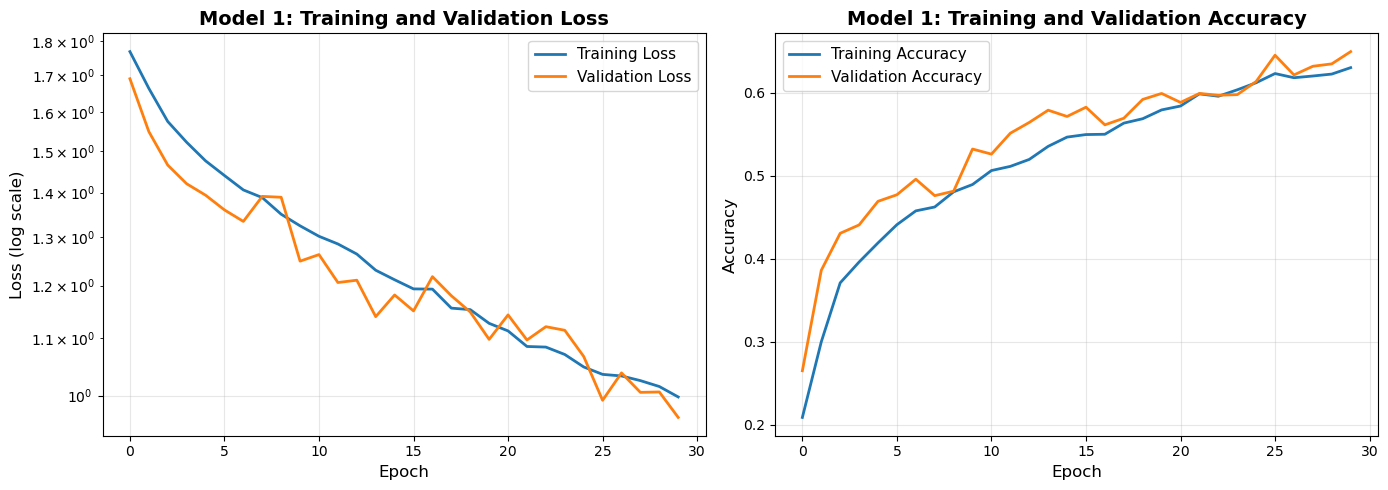

In [ ]:
model_4 = create_cnn_model_2(num_branches = [
											[(32, (3,3))], 
											[(32, (1,1)), (64, (3,3))],
											[(32, (1,1)), (64, (3,3)), (64, (3,3))]
										 ], dense_layer_sizes = [64, 32, 16, 6], use_dropout=False)

model_4.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history4 = model_4.fit(train_ds, validation_data=test_ds, batch_size=32, epochs=30, shuffle=True, verbose=1)

model_4.summary()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot (log scale)
axes[0].semilogy(history4.history['loss'], label='Training Loss', linewidth=2)
axes[0].semilogy(history4.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss (log scale)', fontsize=12)
axes[0].set_title('Model 1: Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history4.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[1].plot(history4.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Model 1: Training and Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Analysis

Mdoel 4 extends the model 3 by adding one more branch of one convulation layer of 32 filter with a 1x1, followed by 2 64 filter layers of 3x33 kernel size. This added branch allows the model to extract more features, at a higher level. After concatenating all of the branches, we then pass it along to the same amount of dense layers as model 3, but dropout is disabled. 

Both the loss curves is decreasing slowly, and are verly close to each other for the entire epochs of 30. This indicates that the model is not overfitting, generlizes well, and is effecting learning after each epochs. The closeness of the curves indicates that the model is fitting the training data well, and also on unseen data. 

The accuracy curves also follows the similar trend of loss curve where the accuracy is increasing steadily, and also nearly overlapping each other as well. Model 4 achives the highest accuracy out of all the models. Overall, the accuracy curve confirms that the additional branch improves the model to learn/extract useful features, and is able to classify the images more accurately. 

#### 2.3 Calculating the F Scores for the classes

In [43]:
#Asked GPT for some weighted f1 help
import numpy as np
from sklearn.metrics import f1_score, fbeta_score
from pprint import pprint

y_true = np.concatenate([y for _, y in test_ds], axis=0)

models_dict = {
	"model_1": model_1,
	"model_2": model_2,
	"model_3": model_3,
	"model_4": model_4
}

models_f2_dict = {
	"model_1": None,
	"model_2": None,
	"model_3": None,
	"model_4": None
}

cardboard = 0
glass = 1
metal = 2
paper = 3
plastic = 4
trash = 5

high_risk = [glass, metal, trash]
low_risk = [cardboard, paper, plastic]

model_pred_result = {
	"model_1": None,
	"model_2": None,
	"model_3": None,
	"model_4": None
}

for model_name in models_dict:
	y_pred_probs = models_dict[model_name].predict(test_ds)
	y_pred = np.argmax(y_pred_probs, axis=1)

	model_pred_result[model_name] = y_pred
	
	f2_high_risk = fbeta_score(y_true, y_pred, beta=2, average=None)
	f1_low_risk = f1_score(y_true, y_pred, average=None)

	glass_f2 = f2_high_risk[glass]
	metal_f2 = f2_high_risk[metal]
	trash_f2 = f2_high_risk[trash]

	paper_f1 = f1_low_risk[paper]
	plastic_f1 = f1_low_risk[plastic]
	cardboard_f1 = f1_low_risk[cardboard]

	final_score = ( 2*(glass_f2 + metal_f2 + trash_f2) + paper_f1 + plastic_f1 + cardboard_f1 ) / 9

	models_f2_dict[model_name] = final_score


pprint(models_f2_dict)
print("The Best Model is ", max(models_f2_dict, key=models_f2_dict.get))
print("The Best Model score is", models_f2_dict[max(models_f2_dict, key=models_f2_dict.get)])

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step
{'model_1': np.float64(0.163911000040495),
 'model_2': np.float64(0.171143569458559),
 'model_3': np.float64(0.16482461213718744),
 'model_4': np.float64(0.1729975496340305)}
The Best Model is  model_4
The Best Model score is 0.1729975496340305


#### Result

We decided to go with a weighted evaluation metric. Since we mention that high risk are glass, metal, and trash, we gave them a 2 times multiplier so that the weight more in the final result as compared to low risk, and then we took the average of the result. 

<br>
After looking at the result, we can see that the model 4 is the best performer but the score is really low suggesting the that the misclassification is high. All the other models were roughly the same performer as well. This suggest that despite having a good validation accuracy for model 2 and 4, the model were not able to correctly label the classes accurate. 

There could be multiple different reasons why the our model is not performing great. Maybe our model is too shallow, or parallel pathway is not a good technique to do classifications for our datasets. 

### 2.4 Statitical Comparison between the models

In [48]:
from statsmodels.stats.contingency_tables import mcnemar
import itertools

result = {}
model_names = ["model_1", "model_2", "model_3", "model_4"]

def mcNemar_table(y_true, model_1_pred, model_2_pred):
	model1_correct = model_1_pred == y_true
	model2_correct = model_2_pred == y_true

	both_correct = np.sum(model1_correct & model2_correct)
	model1_correct_model2_wrong = np.sum(model1_correct & ~model2_correct)
	model2correct_model1_wrong = np.sum(~model1_correct & model2_correct)
	both_wrong = np.sum(~model1_correct & ~model2_correct)

	return np.array([[both_correct, model1_correct_model2_wrong], [model2correct_model1_wrong, both_wrong]])

for model1, model2 in itertools.combinations(model_names, 2):
	table = mcNemar_table(y_true, model_pred_result[model1], model_pred_result[model2])
	result_mcnemar = mcnemar(table, exact=False, correction=True)
	result[(model1, model2)] = {
			"statistic": result_mcnemar.statistic,
			"p-value": result_mcnemar.pvalue
		}

{('model_1', 'model_2'): {'p-value': np.float64(0.35095174570141496),
                          'statistic': np.float64(0.87001287001287)},
 ('model_1', 'model_3'): {'p-value': np.float64(0.4707751244578515),
                          'statistic': np.float64(0.5201560468140443)},
 ('model_1', 'model_4'): {'p-value': np.float64(0.43174103666997876),
                          'statistic': np.float64(0.6181353767560664)},
 ('model_2', 'model_3'): {'p-value': np.float64(0.8580950319217497),
                          'statistic': np.float64(0.0319693094629156)},
 ('model_2', 'model_4'): {'p-value': np.float64(0.914783857819155),
                          'statistic': np.float64(0.011450381679389313)},
 ('model_3', 'model_4'): {'p-value': np.float64(0.9717256517676035),
                          'statistic': np.float64(0.001256281407035176)}}


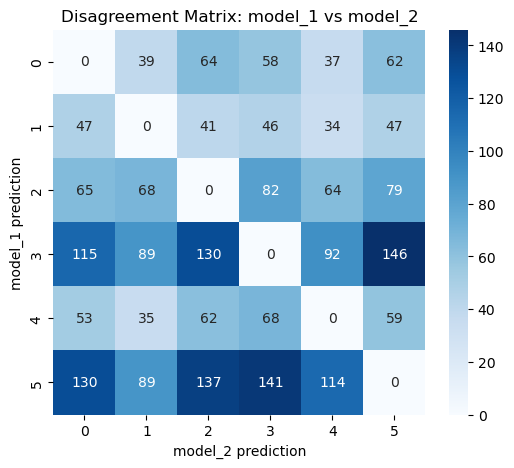

mcNemar Result {'statistic': np.float64(0.87001287001287), 'p-value': np.float64(0.35095174570141496)}


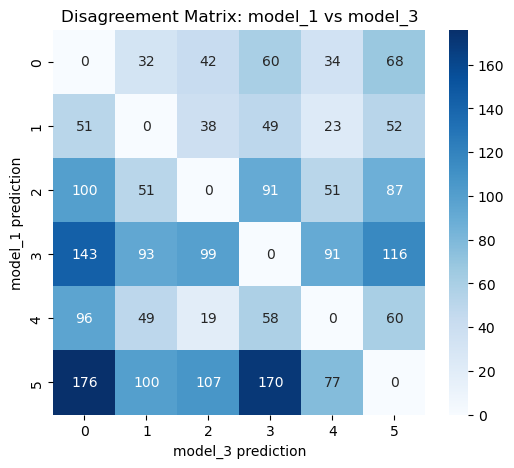

mcNemar Result {'statistic': np.float64(0.5201560468140443), 'p-value': np.float64(0.4707751244578515)}


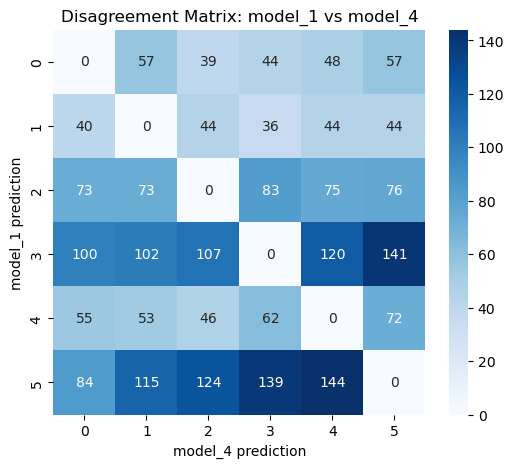

mcNemar Result {'statistic': np.float64(0.6181353767560664), 'p-value': np.float64(0.43174103666997876)}


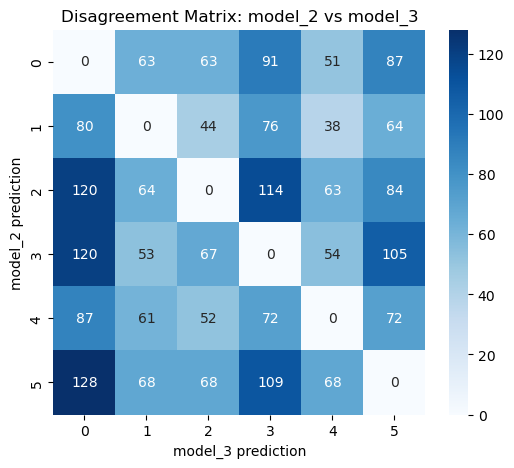

mcNemar Result {'statistic': np.float64(0.0319693094629156), 'p-value': np.float64(0.8580950319217497)}


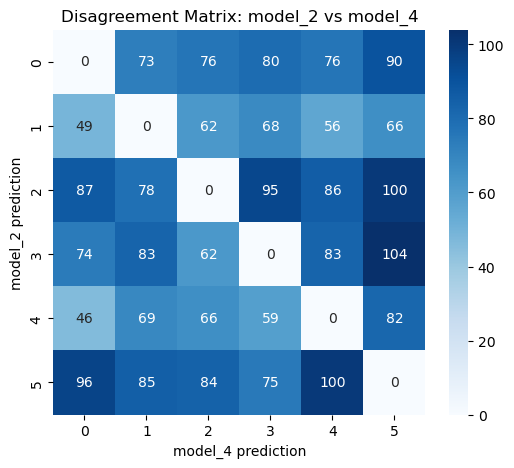

mcNemar Result {'statistic': np.float64(0.011450381679389313), 'p-value': np.float64(0.914783857819155)}


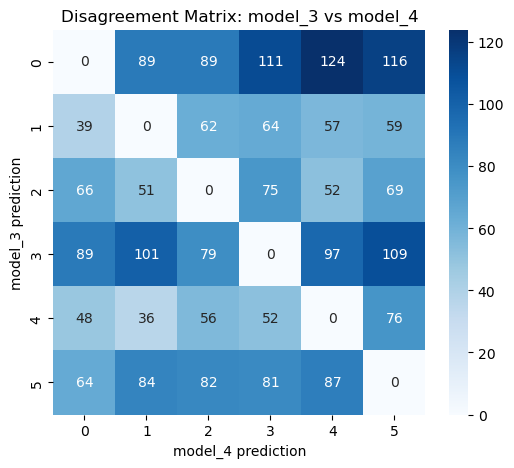

mcNemar Result {'statistic': np.float64(0.001256281407035176), 'p-value': np.float64(0.9717256517676035)}


In [59]:
#Asked Gpt to help plotting confusion matrix, and fixing label names
import seaborn as sns
import sklearn.metrics as mt

def plot_disagreement_matrix(pred_model1, pred_model2, model_1, model2, data):
	name_1 = model_1 if isinstance(model_1, str) else model_1.name
	name_2 = model2 if isinstance(model2, str) else model2.name

	mask = pred_model1 != pred_model2
	disagree_a = pred_model1[mask]
	disagree_b = pred_model2[mask]

	cm = mt.confusion_matrix(disagree_a, disagree_b)

	plt.figure(figsize=(6,5))

	sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
	plt.xlabel(f"{model2} prediction")
	plt.ylabel(f"{model_1} prediction")
	plt.title(f"Disagreement Matrix: {name_1} vs {name_2}")
	plt.show()

	print("mcNemar Result", data)

for (m1, m2), data in result.items():
	plot_disagreement_matrix(model_pred_result[m1], model_pred_result[m2], m1, m2, data)

#### Result

<b>Model 1 vs Model 2</b><br>
From the P result, the values is 0.35 indicating that both models have no statistical difference. 

The matrix shows that that there are large disagreement between paper, and trash. Model 1 predicts labels of paper or trash differently than model 2, and model 2 behaves more consistently with the other labels. 

<b>Model 1 vs Model 3</b><br>
The P result shows that the models are not significantly different from one another. 

The matrix shows a similar trend with the model 1 vs 2. Trash, and paper rows still shows a high disagreement between models. Model 3 which is using dropout, and parallel pathways makes different decisions on sample that looks similar to one another. 

<b>Model 1 vs Model 4</b><br>
The P result shows that the models are not significantly different from one another. 

Since we are still comparing model 1 with other models, the trend still follows where the there is a high disagreement for paper, and trash labels. Model 4 disagrees with less with model 1 for cardboard and plastic compared to model 2, and 3. Additionally, model 4 seems to be making predictions that aligns with model 1. 

<b>Model 2 vs Model 3</b><br>
The P result for is 0.85, which indicates that the model have the same error rate. 

This time, model 3 predicts cardboard more often than model 2, and is still struggling to differentiate between trash and paper. Since we are also using dropout for model 3, it increases the prediction variability. 

<b>Model 2 vs Model 4</b><br>
The P result for this is 0.91, indicating that the models are the same with error rate. 

The matrix between the 2 models has a high disagreement in all the classes. Model has a high disagreement rate for metal, while the model 4 has a high disagreement with trash. 

<b>Model 3 vs Model 4</b><br>
The P result is the highest compared to all the other models with a value of 0.97 suggesting that the models are statically the same.

Model 3 has a high disagreement for cardboard and paper compare to model 4, while model 4 is able to predict with less disagreement with the other models. 

Overall, this suggest that this dataset is difficult to classify despite achieving a relativity good accuracy, and it looks like each model is struggling to classify the classes correctly, and these labels were the most difficult for the models to predict: paper, trash, and metal. Which is likely due to them being looking near identical to one another. 

### 2.5 Comparing best result to standard MLP 

Epoch 1/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.2073 - loss: 1.7887 - val_accuracy: 0.2634 - val_loss: 1.7216
Epoch 2/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2739 - loss: 1.6909 - val_accuracy: 0.3080 - val_loss: 1.6586
Epoch 3/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3166 - loss: 1.6377 - val_accuracy: 0.2854 - val_loss: 1.6731
Epoch 4/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3200 - loss: 1.6211 - val_accuracy: 0.3329 - val_loss: 1.6201
Epoch 5/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3382 - loss: 1.5960 - val_accuracy: 0.3660 - val_loss: 1.5677
Epoch 6/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3528 - loss: 1.5765 - val_accuracy: 0.3447 - val_loss: 1.6077
Epoch 7/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3621 - loss: 1.5605 - val_accuracy: 0.3750 - val_loss: 1.5674
Epoch 8/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3638 - loss: 1.5518 - val_accuracy: 0.

Model: "functional_46"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mlp_dense_1 (Dense)             │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mlp_dense_2 (Dense)             │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mlp_dense_3 (Dense)             │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mlp_dense_4 (Dense)             │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mlp_output (Dense)              │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,276,788 (12.50 MB)

 Trainable params: 1,092,262 (4.17 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,184,526 (8.33 MB)

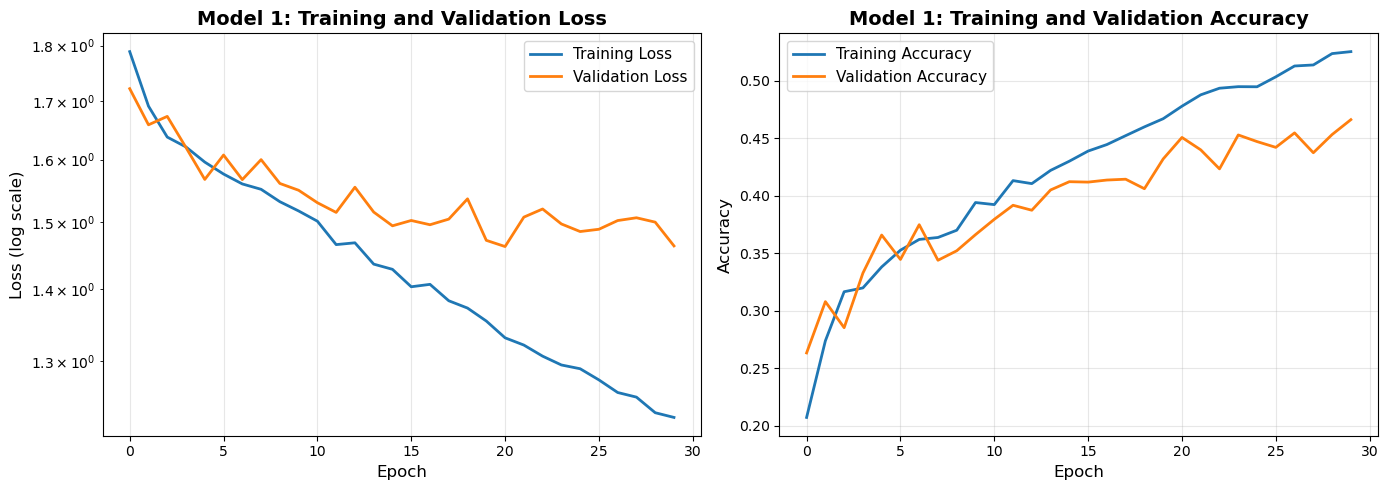

In [ ]:
def four_layer_MLP():
	inputs = tf.keras.Input(shape=(64, 64, 1))
	flatten = Flatten()(inputs)

	layer1 = tf.keras.layers.Dense(256, activation="relu", name="mlp_dense_1")(flatten)
	layer2 = tf.keras.layers.Dense(128, activation="relu", name="mlp_dense_2")(layer1)
	layer3 = tf.keras.layers.Dense(64, activation="relu", name="mlp_dense_3")(layer2)
	layer4 = tf.keras.layers.Dense(32, activation="relu", name="mlp_dense_4")(layer3)

	output = tf.keras.layers.Dense(6, activation="softmax", name="mlp_output")(layer4)

	model = tf.keras.Model(inputs=inputs, outputs=output)
	return model

standard_mlp = four_layer_MLP()

standard_mlp.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history_standard_mlp = standard_mlp.fit(train_ds, validation_data=test_ds, batch_size=32, epochs=30, shuffle=True, verbose=1)

standard_mlp.summary()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot (log scale)
axes[0].semilogy(history_standard_mlp.history['loss'], label='Training Loss', linewidth=2)
axes[0].semilogy(history_standard_mlp.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss (log scale)', fontsize=12)
axes[0].set_title('Standard Multi Layer: Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history_standard_mlp.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[1].plot(history_standard_mlp.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Standard Multi Layer: Training and Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Analysis

We created a standard 4 Layer perceptron, with no dropout or data augmentation. 

The loss curve shows a downward trends for the training loss, but the model is also overfitting to the data set. As indicated by the large gap between training, and the validation loss. 

The accuracy curve shows a consistent increasing trend, but the validation accuracy, but the accuracy achieved is still only 46% for the validation, indicating that the model is still struggling to identify the correct labels. 

In [66]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
from tensorflow.keras.utils import to_categorical

y_true_onehot = to_categorical(y_true, num_classes=6)

model4_pred = model_2.predict(test_ds)
mlp_pred = standard_mlp.predict(test_ds)

def plot_roc_curves(model_name, y_true_onehot, y_pred_probs):
  plt.figure(figsize=(8, 6))

  for c in range(6):
    fpr, tpr, _ = roc_curve(y_true_onehot[:, c], y_pred_probs[:, c])
    auc_score = auc(fpr, tpr)

    plt.plot(fpr, tpr, lw=2, label=f"Class {c} (AUC={auc_score:.3f})")

  plt.plot([0,1], [0,1], "k--", lw=1, label="Random Chance")
  plt.title(f"ROC Curves — {model_name}")
  plt.xlabel("False Positive Rate")
  plt.ylabel("True Positive Rate")
  plt.legend()
  plt.grid(True)
  plt.show()

def compute_per_class_auroc(y_true_onehot, y_pred_probs):
  auc_list = []
  for c in range(6):
    auc_value = roc_auc_score(y_true_onehot[:, c], y_pred_probs[:, c])
    auc_list.append(auc_value)
  return auc_list

def weighted_auroc(per_class_auc):
  cardboard = 0
  glass = 1
  metal = 2
  paper = 3
  plastic = 4
  trash = 5

  high_risk = [glass, metal, trash]
  low_risk  = [cardboard, paper, plastic]

  high_sum = sum(per_class_auc[c] for c in high_risk)
  low_sum  = sum(per_class_auc[c] for c in low_risk)

  return (2 * high_sum + low_sum) / 9

44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


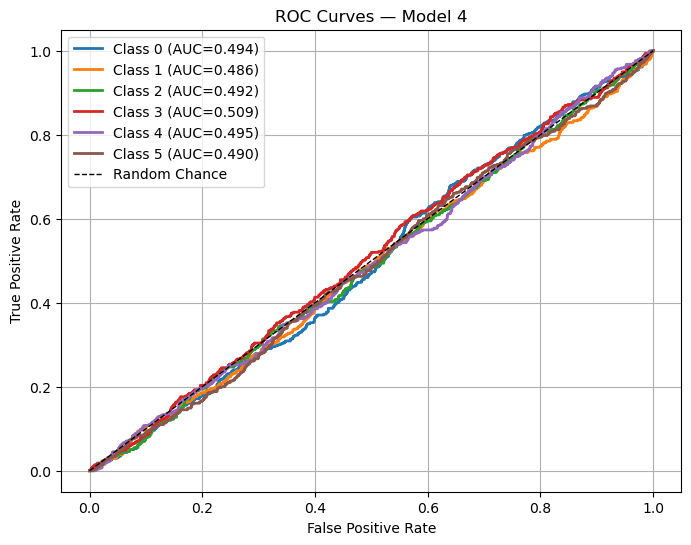

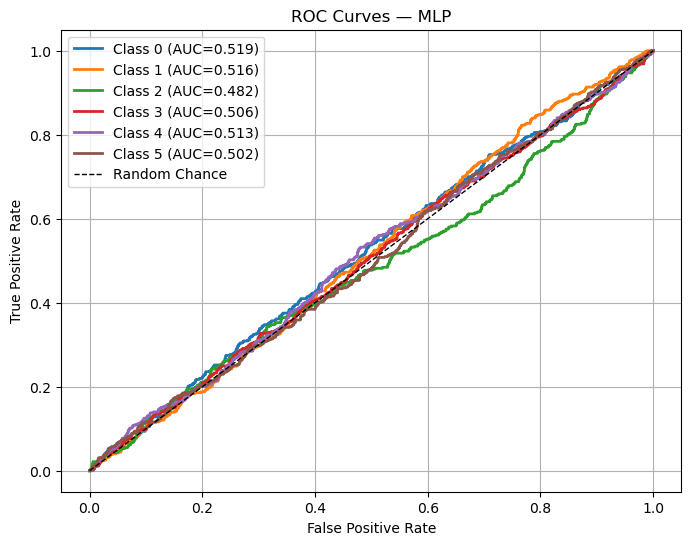

In [69]:
plot_roc_curves("Model 4", y_true_onehot, model4_pred)

plot_roc_curves("MLP", y_true_onehot, mlp_pred)

#### Analysis

The ROC curves gives us a better understanding on what the mode is doing. For both the models 4, and standard, they are randomly guessing the classes as indicated by the AUC, and the near identical line. The F2 score for the best performer now makes sense with its low values, as the model is randomly guessing the correct labels across all 6 classes. 

The classes are equally distributed, but it is difficult to classifies the dataset as we resize it to a 64x64 image, and also turned into a grey image. So the images might have lost some features that could CNN to learn/extract more useful features to train the model. Additionally, some of the images are hard to distinguishable due to the loss in quality, so the model would struggle with it as well.

Creating parallel pathways did not make a difference in the model classifying the datasets, despite achieving high accuracy result. I believe that having more layers, and playing around with the learning rate might improve the result, but the garbage dataset is overall difficult to classify with our current models. 